# Importing Library/checking Datasets

In [123]:
#Importing Libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns





## Uploading CSV and Identifying shape

In [124]:


matches    = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')
orange_cap = pd.read_csv('orange_cap.csv')
purple_cap = pd.read_csv('purple_cap.csv')

print("matches:",    matches.shape)
print("deliveries:", deliveries.shape)
print("orange_cap:", orange_cap.shape)
print("purple_cap:", purple_cap.shape)


matches: (74, 22)
deliveries: (17183, 19)
orange_cap: (15, 16)
purple_cap: (15, 14)


#### Checking Columns of Match Table

In [125]:


print(matches.head())

   match_id           date                                          venue  \
0         1  March 22,2025                          Eden Gardens, Kolkata   
1         2  March 23,2025  Rajiv Gandhi International Stadium, Hyderabad   
2         3  March 23,2025                MA Chidambaram Stadium, Chennai   
3         4  March 24,2025       ACA-VDCA Cricket Stadium, Vishakhapatnam   
4         5  March 25,2025               Narendra Modi Stadium, Ahmedabad   

  team1 team2   stage toss_winner toss_decision  first_ings_score  \
0   KKR   RCB  League         RCB          Bowl             174.0   
1   SRH    RR  League          RR          Bowl             286.0   
2   CSK    MI  League         CSK          Bowl             155.0   
3    DC   LSG  League          DC          Bowl             209.0   
4    GT  PBKS  League          GT          Bowl             243.0   

   first_ings_wkts  ...  match_result  match_winner wb_runs wb_wickets  \
0              8.0  ...     completed           

##### Checking Nulls


In [126]:


print(matches.isnull().sum())

match_id                0
date                    0
venue                   0
team1                   0
team2                   0
stage                   0
toss_winner             1
toss_decision           0
first_ings_score        1
first_ings_wkts         1
second_ings_score       2
second_ings_wkts        2
match_result            0
match_winner            3
wb_runs                40
wb_wickets             36
balls_left              2
player_of_the_match     3
top_scorer              3
highscore               3
best_bowling            3
best_bowling_figure     3
dtype: int64


# Cleaning Data

In [127]:

#(Removed because of no Outcome)draw
matches=matches[matches['match_result']=='completed']
print(matches.isnull().sum())

match_id                0
date                    0
venue                   0
team1                   0
team2                   0
stage                   0
toss_winner             0
toss_decision           0
first_ings_score        0
first_ings_wkts         0
second_ings_score       0
second_ings_wkts        0
match_result            0
match_winner            0
wb_runs                37
wb_wickets             33
balls_left              0
player_of_the_match     0
top_scorer              0
highscore               0
best_bowling            0
best_bowling_figure     0
dtype: int64


#### Saving File after cleaning

In [128]:


matches.to_csv('matches_clean.csv', index=False)
print("matches_clean.csv saved!")

matches_clean.csv saved!


##### Cleaning delveries data

In [129]:


print(deliveries.isnull().sum())

match_no                0
date                    0
stage                   0
venue                   0
batting_team            0
bowling_team            0
innings                 0
over                    0
striker                 0
bowler                  0
runs_of_bat             0
extras                  0
wide                    0
legbyes                 0
byes                    0
noballs                 0
wicket_type         16311
player_dismissed    16311
fielder             16504
dtype: int64


####  Filling Nulls

In [130]:

# No wicket fall ,players dismissed and no fielder involved in Dismissal

deliveries['wicket_type'] = deliveries['wicket_type'].fillna('none')
deliveries['player_dismissed'] = deliveries['player_dismissed'].fillna('none')
deliveries['fielder'] = deliveries['fielder'].fillna('none')

print(deliveries.isnull().sum())

match_no            0
date                0
stage               0
venue               0
batting_team        0
bowling_team        0
innings             0
over                0
striker             0
bowler              0
runs_of_bat         0
extras              0
wide                0
legbyes             0
byes                0
noballs             0
wicket_type         0
player_dismissed    0
fielder             0
dtype: int64


#### Adding Columns

In [131]:
# Adding Few Columns(is_wicket,is_four,is_six)

deliveries['is_wicket']=(deliveries['wicket_type'] !='none').astype(int)
deliveries['is_four']=(deliveries['runs_of_bat']==4).astype(int)
deliveries['is_six']=(deliveries['runs_of_bat']==6).astype(int)

print("Total wickets:", deliveries['is_wicket'].sum())
print("Total fours:", deliveries['is_four'].sum())
print("Total sixes:", deliveries['is_six'].sum())


Total wickets: 872
Total fours: 2251
Total sixes: 1297


##### Saving deliveries csv

In [132]:


deliveries.to_csv('deliveries_clean.csv',index=False)
print("deliveries_clean.csv saved !")


deliveries_clean.csv saved !


In [133]:
# Checking null of orange_cap ,purple_cap

print(orange_cap.isnull().sum())
print(purple_cap.isnull().sum())

Position         0
Batsman          0
Team             0
Matches          0
Innings          0
Not_out          0
Runs             0
Highest_score    0
Average          0
Balls_faced      0
Strike_rate      0
Hundreds         0
Fifties          0
Ducks            0
Fours            0
Sixes            0
dtype: int64
Position               0
Bowler                 0
Team                   0
Matches                0
Innings                0
Balls                  0
Overs                  0
Maidens                0
Runs                   0
Wickets                0
Best_bowling_figure    0
Economy_rate           0
Four_wicket_haul       0
Five_wicket_hall       0
dtype: int64


# Player Performance Analysis

## Batting Analysis


#### Top 10 Run Scorers

In [136]:


top_batters=deliveries.groupby('striker').sum('runs_of_bat').sort_values(by='runs_of_bat',ascending=False).head(10)

top_batters = top_batters[['runs_of_bat', 'is_four', 'is_six']]
top_batters.columns = ['Runs', 'Fours', 'Sixes']
print(top_batters)


                  Runs  Fours  Sixes
striker                             
Sai Sudharsan      759     88     21
Suryakumar Yadav   717     69     38
Kohli              657     66     19
Shubman Gill       650     62     24
Mitchell Marsh     627     56     37
Shreyas Iyer       604     43     39
Jaiswal            559     60     28
Prabhsimran        549     56     30
Rahul              546     53     21
Buttler            538     52     24


####  chart of Top 10 scorers


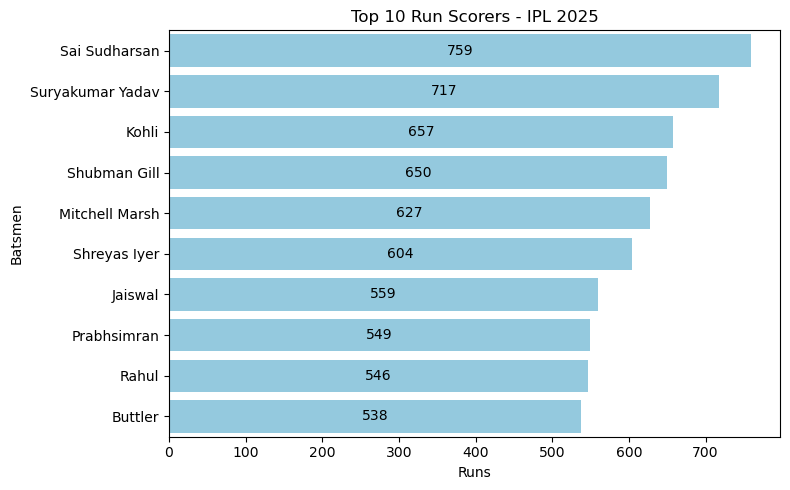

In [173]:


plt.figure(figsize=(8, 5))
ax=sns.barplot(data=top_batters,x='Runs',y='striker',color='skyblue')
for container in ax.containers:
    ax.bar_label(container,label_type='center')
plt.title("Top 10 Run Scorers - IPL 2025")
plt.xlabel('Runs')
plt.ylabel('Batsmen')
plt.tight_layout()
plt.savefig('Top 10 Run Scorers - IPL 2025.png', dpi=150, bbox_inches='tight')
plt.show()




#### Top 10 batsman with highest strike rate (atleast played 200 balls)

In [142]:


strike_rate=deliveries[deliveries['wide']==0].groupby('striker').agg(
    Runs=('runs_of_bat','sum'),
    Balls=('runs_of_bat','count'))
strike_rate['Strike_Rate'] = (strike_rate['Runs'] / strike_rate['Balls'] * 100).round(2)
strike_rate = strike_rate[strike_rate['Balls'] >= 200]  
strike_rate = strike_rate.sort_values('Strike_Rate', ascending=False).head(10)
strike_rate = strike_rate.reset_index()
strike_rate.index=strike_rate.index+1
print(strike_rate)
    
    

             striker  Runs  Balls  Strike_Rate
1             Pooran   524    267       196.25
2    Abhishek Sharma   439    227       193.39
3      Priyansh Arya   475    265       179.25
4          Phil Salt   403    229       175.98
5       Shreyas Iyer   604    345       175.07
6            Klaasen   487    282       172.70
7   Suryakumar Yadav   717    427       167.92
8        Riyan Parag   393    236       166.53
9     Mitchell Marsh   627    383       163.71
10           Buttler   538    330       163.03


##### Chart For Top 10 strike rate batsman

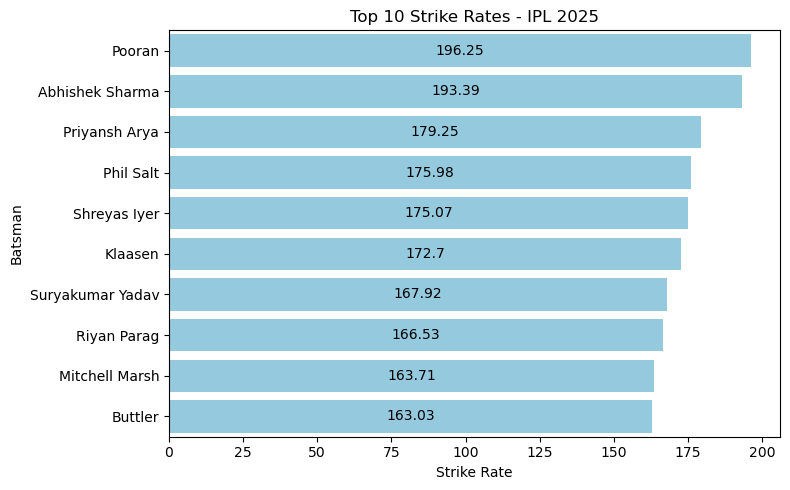

In [172]:


plt.figure(figsize=(8,5))
ax=sns.barplot(data=strike_rate,x='Strike_Rate',y='striker',color='skyblue')
for container in ax.containers:
    ax.bar_label(container,label_type='center')
plt.title("Top 10 Strike Rates - IPL 2025")
plt.xlabel('Strike Rate')
plt.ylabel('Batsman')
plt.tight_layout()
plt.savefig('Top 10 Strike Rates - IPL 2025', dpi=150, bbox_inches='tight')
plt.show()

    

#### Top Six Hitter 

In [144]:


top_six_hitters=deliveries.groupby('striker')['is_six'].sum().sort_values(ascending=False).reset_index().head(10)
top_six_hitters.columns = ['Batsman', 'Sixes']
top_six_hitters.index = top_six_hitters.index + 1
print(top_six_hitters)






             Batsman  Sixes
1             Pooran     40
2       Shreyas Iyer     39
3   Suryakumar Yadav     38
4     Mitchell Marsh     37
5        Prabhsimran     30
6    Abhishek Sharma     28
7            Jaiswal     28
8        Riyan Parag     27
9            Klaasen     25
10     Priyansh Arya     25


#### Chart of top 10 Six hitters

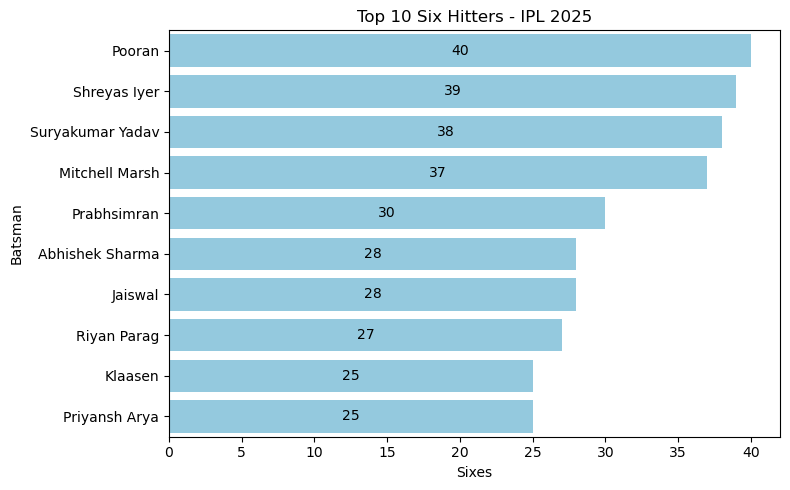

In [171]:


plt.figure(figsize=(8, 5))
ax = sns.barplot(data=top_six_hitters, x='Sixes', y='Batsman',color='skyblue')
for container in ax.containers:
    ax.bar_label(container, label_type='center')
plt.title("Top 10 Six Hitters - IPL 2025")
plt.xlabel('Sixes')
plt.ylabel('Batsman')
plt.tight_layout()
plt.savefig('Top 10 Six Hitters - IPL 2025.png', dpi=150, bbox_inches='tight')
plt.show()


### Top 10 Batsman with fours

In [147]:


top_four_hitters = deliveries.groupby('striker')['is_four'].sum()
top_four_hitters = top_four_hitters.sort_values(ascending=False).head(10)
top_four_hitters = top_four_hitters.reset_index()
top_four_hitters.columns = ['Batsman', 'Fours']
top_four_hitters.index = top_four_hitters.index + 1
print(top_four_hitters)

             Batsman  Fours
1      Sai Sudharsan     88
2   Suryakumar Yadav     69
3              Kohli     66
4       Shubman Gill     62
5            Jaiswal     60
6     Mitchell Marsh     56
7        Prabhsimran     56
8      Priyansh Arya     55
9              Rahul     53
10           Buttler     52


### Chart of top 10 Batsman with four

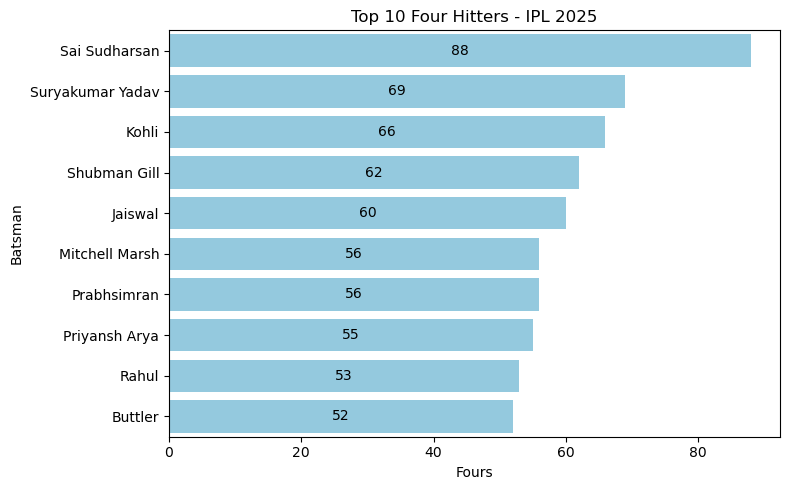

In [170]:


plt.figure(figsize=(8,5))
ax=sns.barplot(data=top_four_hitters,x='Fours',y='Batsman',color='skyblue')
for container in ax.containers:
    ax.bar_label(container,label_type='center')
plt.title("Top 10 Four Hitters - IPL 2025")
plt.xlabel('Fours')
plt.ylabel('Batsman')
plt.tight_layout()
plt.savefig('Top 10 Four Hitters - IPL 2025', dpi=150, bbox_inches='tight')
plt.show()

    

# Bowling Analysis


### Top 10 Wicket Takers

In [102]:


top_wicket_taker=deliveries.groupby('bowler')['is_wicket'].sum()
top_wicket_taker=top_wicket_taker.sort_values(ascending=False)
top_wicket_taker = top_wicket_taker.reset_index().head(10)
top_wicket_taker.columns = ['Bowler', 'Wickets']
top_wicket_taker.index=top_wicket_taker.index+1

print(top_wicket_taker)



            Bowler  Wickets
1          Prasidh       26
2       Noor Ahmad       24
3            Boult       23
4        Hazlewood       22
5   Arshdeep Singh       22
6           Bumrah       21
7   Mitchell Starc       19
8    Vaibhav Arora       19
9      Sai Kishore       19
10     Bhuvneshwar       18


#### Chart for Top 10 Wicket Takers

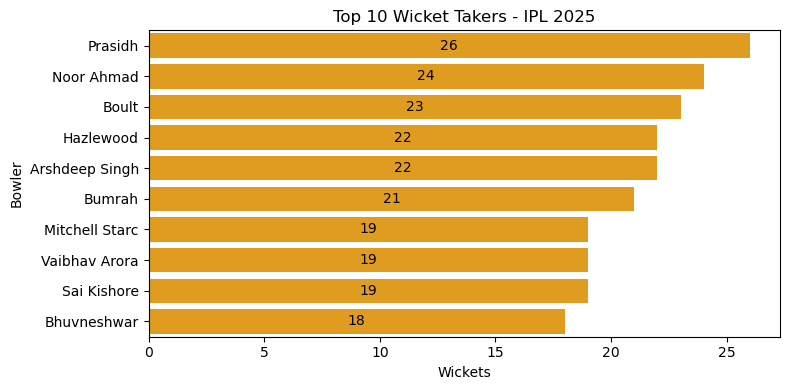

In [169]:


plt.figure(figsize=(8,4))
ax=sns.barplot(data=top_wicket_taker,x='Wickets',y='Bowler',color='orange')
for container in ax.containers:
      ax.bar_label(container,label_type='center')
plt.title( "Top 10 Wicket Takers - IPL 2025")
plt.xlabel('Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.savefig('Top 10 Wicket Takers - IPL 2025.png', dpi=150, bbox_inches='tight')
plt.show()

    

#### Best economy bowler

In [151]:


economy = deliveries.groupby('bowler').agg(
    Runs = ('runs_of_bat', 'sum'),
    Wides = ('wide', 'sum'),
    NoBalls = ('noballs', 'sum'),
    Balls = ('wide', lambda x: ((x == 0) & (deliveries.loc[x.index, 'noballs'] == 0)).sum())
)
economy['Total_Runs'] = economy['Runs'] + economy['Wides'] + economy['NoBalls']
economy['Economy_per_over'] = ((economy['Total_Runs'] * 6) / economy['Balls']).round(2)
economy = economy[economy['Balls'] >= 60]
economy = economy.sort_values('Economy_per_over', ascending=True).head(10)
economy = economy.reset_index()
economy.index = economy.index + 1
print(economy[['bowler', 'Total_Runs', 'Balls', 'Economy_per_over']])

                 bowler  Total_Runs  Balls  Economy_per_over
1                Bumrah         316    284              6.68
2         Kuldeep Yadav         361    306              7.08
3               Unadkat         175    143              7.34
4   Varun Chakaravarthy         383    300              7.66
5                Narine         351    270              7.80
6               Santner         312    237              7.90
7            Mustafizur          87     66              7.91
8         Anshul Kamboj         172    129              8.00
9            Noor Ahmad         400    300              8.00
10        Digvesh Rathi         425    312              8.17


#### Chart of Top 10 Economic Bowlers

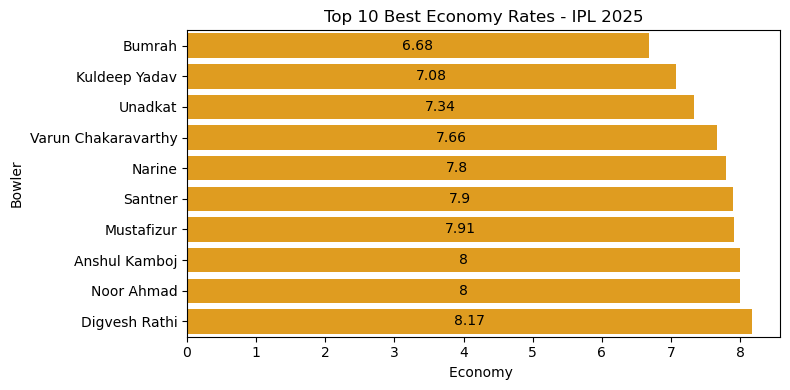

In [168]:


plt.figure(figsize=(8,4))
ax=sns.barplot(data=economy,x='Economy_per_over',y='bowler',color='orange')
for container in ax.containers:
    ax.bar_label(container,label_type='center')
plt.title( "Top 10 Best Economy Rates - IPL 2025")
plt.xlabel('Economy ')
plt.ylabel('Bowler')
plt.tight_layout()
plt.savefig('Top 10 Best Economy Rates - IPL 2025.png', dpi=150, bbox_inches='tight')
plt.show()

    

#### Most Dot Percentage wise

In [153]:


deliveries['is_dot'] = ((deliveries['runs_of_bat'] == 0) & 
                        (deliveries['wide'] == 0) & 
                        (deliveries['noballs'] == 0)).astype(int)
dot_balls = deliveries.groupby('bowler').agg(
    Dots = ('is_dot', 'sum'),
    Balls = ('wide', lambda x: ((x == 0) & (deliveries.loc[x.index, 'noballs'] == 0)).sum())
)
dot_balls['Dot%'] = ((dot_balls['Dots'] / dot_balls['Balls']) * 100).round(2)
dot_balls = dot_balls[dot_balls['Balls'] >= 120]
dot_balls = dot_balls.sort_values('Dot%', ascending=False).head(10)
dot_balls = dot_balls.reset_index()
dot_balls.index = dot_balls.index + 1
print(dot_balls[['bowler', 'Dots', 'Balls', 'Dot%']])


           bowler  Dots  Balls   Dot%
1   Khaleel Ahmed   137    280  48.93
2       Hazlewood   120    264  45.45
3          Bumrah   128    284  45.07
4           Siraj   151    342  44.15
5          Chahar   108    246  43.90
6   Anshul Kamboj    56    129  43.41
7         Prasidh   146    354  41.24
8    Marco Jansen   116    283  40.99
9    Jofra Archer   110    273  40.29
10   Harshit Rana   105    264  39.77


#### Chart For Top Dot Delivery Bowler

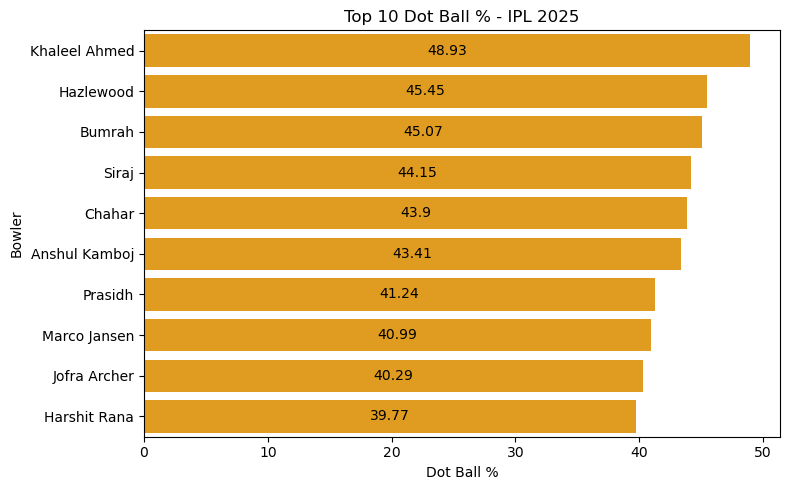

In [167]:


plt.figure(figsize=(8, 5))
ax = sns.barplot(data=dot_balls, x='Dot%', y='bowler', color='orange')
for containers in ax.containers:
    ax.bar_label(containers, label_type='center')
plt.title("Top 10 Dot Ball % - IPL 2025")
plt.xlabel('Dot Ball %')
plt.ylabel('Bowler')
plt.tight_layout()
plt.savefig('Top 10 Dot Ball % - IPL 2025.png', dpi=150, bbox_inches='tight')
plt.show()


# Over Analysis

#### Runs Per Over

In [93]:


deliveries['over_no']=deliveries['over'].astype(int)
runs_per_over=deliveries.groupby('over_no')['runs_of_bat'].sum().head(20)
runs_per_over=runs_per_over.reset_index()
runs_per_over['over_no']=runs_per_over['over_no']+1
runs_per_over['Avg_run_per_over']=runs_per_over['runs_of_bat']//142
#divided by 142 because of 71 matches and 2 inings per match
print(runs_per_over)

    over_no  runs_of_bat  Avg_run_per_over
0         1         1014                 7
1         2         1269                 8
2         3         1384                 9
3         4         1451                10
4         5         1348                 9
5         6         1444                10
6         7         1145                 8
7         8         1145                 8
8         9         1177                 8
9        10         1264                 8
10       11         1306                 9
11       12         1243                 8
12       13         1304                 9
13       14         1258                 8
14       15         1252                 8
15       16         1298                 9
16       17         1225                 8
17       18         1301                 9
18       19         1219                 8
19       20         1149                 8


#### Chart Of Over Analysis


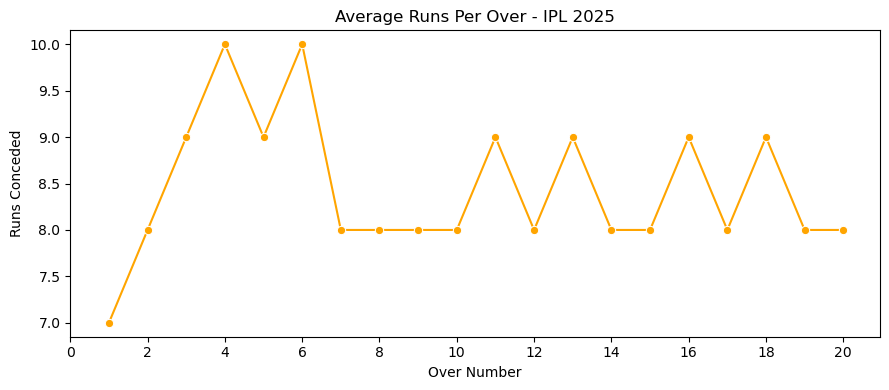

In [166]:

plt.figure(figsize=(9,4))
sns.lineplot(data=runs_per_over,x='over_no',y='Avg_run_per_over',color='orange',marker='o')
plt.xticks(range(0, 22, 2))
plt.title("Average Runs Per Over - IPL 2025")
plt.xlabel('Over Number')
plt.ylabel('Runs Conceded')
plt.tight_layout()
plt.savefig('Average Runs Per Over - IPL 2025.png' , dpi=150 ,bbox_inches='tight')
plt.show()



# Team Analysis

## Toss Impact

##### How much mach won who won toss(%)

In [158]:


matches['toss_win_match_win'] = (matches['toss_winner'] == matches['match_winner']).astype(int)

toss_impact = matches['toss_win_match_win'].value_counts()

toss_impact_pct = (matches['toss_win_match_win'].value_counts(normalize=True) * 100).round(2)
print(toss_impact_pct)

print("Toss won and match won:", toss_impact[1], f"({toss_impact_pct[1]}%)")
print("Toss won but match lost:", toss_impact[0], f"({toss_impact_pct[0]}%)")

toss_win_match_win
1    59.15
0    40.85
Name: proportion, dtype: float64
Toss won and match won: 42 (59.15%)
Toss won but match lost: 29 (40.85%)


#### chart of Toss Impact

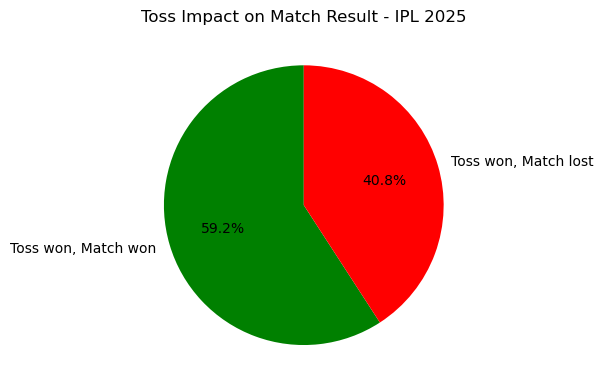

In [165]:


plt.figure(figsize=(8,4))
plt.pie(
    toss_impact,labels=['Toss won, Match won', 'Toss won, Match lost'],autopct='%1.1f%%',colors=['green', 'red'],
    startangle=90
)
plt.title("Toss Impact on Match Result - IPL 2025")
plt.tight_layout()
plt.savefig("Toss Impact on Match Result - IPL 2025.png",dpi=150,bbox_inches='tight')
plt.show()


#### Win % By Team

In [22]:




team_1 = matches['team1'].value_counts()
team_2 = matches['team2'].value_counts()
total_matches = team_1.add(team_2, fill_value=0)


matches_win_count=matches['match_winner'].value_counts()
match_win_percentage=round(((matches_win_count/total_matches)*100),2)
match_win_percentage=match_win_percentage.reset_index()
match_win_percentage.columns=['teams','win_percentage']
print(match_win_percentage)

  teams  win_percentage
0   CSK           28.57
1    DC           61.54
2    GT           60.00
3   KKR           41.67
4   LSG           42.86
5    MI           50.00
6  PBKS           68.75
7   RCB           66.67
8    RR           28.57
9   SRH           46.15


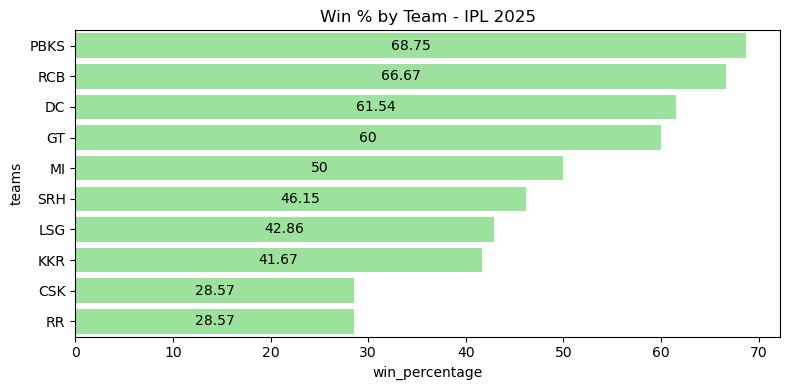

In [164]:
# Chart For Win% by teams

plt.figure(figsize=(8,4))
ax=sns.barplot(data=match_win_percentage,x='win_percentage',y='teams',color='lightgreen',
               order=match_win_percentage.sort_values('win_percentage', ascending=False)['teams'])
for containers in ax.containers:
    ax.bar_label(containers,label_type='center')
plt.title("Win % by Team - IPL 2025")
plt.xlabel('win_percentage')
plt.ylabel('teams')
plt.tight_layout()
plt.savefig('Win % by Team - IPL 2025.png', dpi=150, bbox_inches='tight')
plt.show()           


#### Winning of ball vs bat first

In [49]:



bat_first=matches[matches['toss_decision']=='Bat']
bat_wins=(bat_first['toss_winner']==bat_first['match_winner']).sum()
bat_total=len(bat_first)
bat_first_win_pct=(bat_wins/bat_total)*100
print("Bat first winning percentage :", bat_first_win_pct)

bowl_first = matches[matches['toss_decision'] == 'Bowl']
bowl_wins = (bowl_first['toss_winner'] == bowl_first['match_winner']).sum()
bowl_total = len(bowl_first)
bowl_first_win_pct = round((bowl_wins / bowl_total) * 100, 2)
print("Bowl first winning percenatage:",bowl_first_win_pct)


Bat first winning percentage : 75.0
Bowl first winning percenatage: 55.93


#### chart for Bat/Ball first winnig percentage

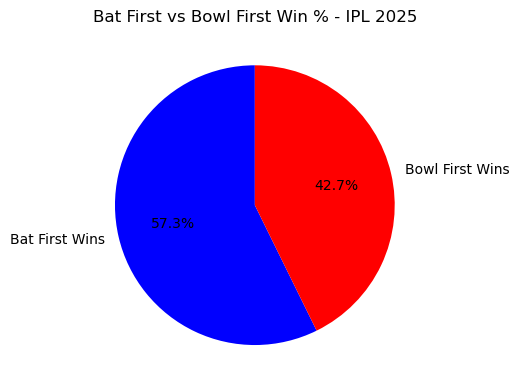

In [163]:


plt.figure(figsize=(8,4))
plt.pie(
    [bat_first_win_pct, bowl_first_win_pct],
    labels=['Bat First Wins', 'Bowl First Wins'],
    autopct='%1.1f%%',
    colors=['blue', 'red'],
    startangle=90
)
plt.title("Bat First vs Bowl First Win % - IPL 2025")
plt.tight_layout()
plt.savefig('Bat First vs Bowl First Win % - IPL 2025', dpi=150, bbox_inches='tight')
plt.show()


# Personal Impact Point Analysis

In [84]:

batting_stat=deliveries[deliveries['wide']==0].groupby('striker').agg(
    Runs=('runs_of_bat','sum'),
    Balls_faced=('runs_of_bat','count')).reset_index()

batting_stat['strike_rate']=round(((batting_stat['Runs']/batting_stat['Balls_faced'])*100),2)

# Bowling

# Create legal_ball column first
deliveries['legal_ball'] = ((deliveries['wide'] == 0) & 
                            (deliveries['noballs'] == 0)).astype(int)

# Now use it in groupby
bowling_stat = deliveries.groupby('bowler').agg(
    Wickets = ('is_wicket', 'sum'),
    Balls_bowled = ('legal_ball', 'sum'),
    Runs_conceded = ('runs_of_bat', 'sum'),
    Wides = ('wide', 'sum'),
    NoBalls = ('noballs', 'sum')
).reset_index()

bowling_stat['Total_Runs'] = bowling_stat['Runs_conceded'] + bowling_stat['Wides'] + bowling_stat['NoBalls']
bowling_stat['Economy'] = ((bowling_stat['Total_Runs'] * 6) / bowling_stat['Balls_bowled']).round(2)


# Catches

catches = deliveries[deliveries['wicket_type'] == 'caught'].groupby('fielder')['wicket_type'].count().reset_index()
catches.columns = ['Player', 'Catches']

# Giving Points

def sr_points(row):
    if row['Balls_faced'] < 50:
        return 0
    sr = row['strike_rate']
    if sr >= 200:
        return 50
    elif sr >= 170:
        return 35
    elif sr >= 150:
        return 20
    elif sr >= 130:
        return 10
    elif sr >= 120:
        return -40
    else:
        return -50



def eco_points(row):
    if row['Balls_bowled'] < 100:
        return 0
    eco = row['Economy']
    if eco < 8:
        return 50
    elif eco < 9:
        return 35
    elif eco < 10:
        return 20
    elif eco < 12:
        return 0
    elif eco < 15:
        return -15
    else:
        return -50



batting_stat['SR_Points'] = batting_stat.apply(sr_points, axis=1)
batting_stat['Run_Points'] = batting_stat['Runs']

bowling_stat['Eco_Points'] = bowling_stat.apply(eco_points, axis=1)
bowling_stat['Wicket_Points'] = bowling_stat['Wickets'] * 30


impact = batting_stat[['striker', 'Runs', 'strike_rate', 'Run_Points', 'SR_Points']].rename(columns={'striker': 'Player'})

impact = impact.merge(
    bowling_stat[['bowler', 'Wickets', 'Economy', 'Wicket_Points', 'Eco_Points']].rename(columns={'bowler': 'Player'}),
    on='Player', how='outer'
).fillna(0)

impact = impact.merge(catches, on='Player', how='left').fillna(0)

impact['Catch_Points'] = impact['Catches'] * 5
impact['Impact_Score'] = (impact['Run_Points'] + impact['SR_Points'] + 
                          impact['Wicket_Points'] + impact['Eco_Points'] + 
                          impact['Catch_Points'])

impact = impact[(impact['Runs'] > 0) | (impact['Wickets'] > 0)]
impact = impact.sort_values('Impact_Score', ascending=False).head(10)
impact = impact.reset_index(drop=True)
impact.index = impact.index + 1

print(impact[['Player', 'Runs', 'strike_rate', 'Wickets', 'Economy', 'Catches', 'Impact_Score']])


              Player   Runs  strike_rate  Wickets  Economy  Catches  \
1            Prasidh    0.0         0.00     26.0     8.25      5.0   
2      Sai Sudharsan  759.0       156.17      0.0     0.00      7.0   
3         Noor Ahmad    7.0        41.18     24.0     8.00      2.0   
4   Suryakumar Yadav  717.0       167.92      0.0     0.00      6.0   
5              Boult    2.0        66.67     23.0     8.90      1.0   
6     Arshdeep Singh    2.0        33.33     22.0     8.79      4.0   
7       Shubman Gill  650.0       156.25      0.0     0.00      8.0   
8             Narine  246.0       170.83     12.0     7.80      3.0   
9          Hazlewood    0.0         0.00     22.0     8.77      1.0   
10     Hardik Pandya  224.0       163.50     14.0     9.69      3.0   

    Impact_Score  
1          840.0  
2          814.0  
3          772.0  
4          767.0  
5          732.0  
6          717.0  
7          710.0  
8          706.0  
9          700.0  
10         699.0  


### Chart for Top Impactful Players

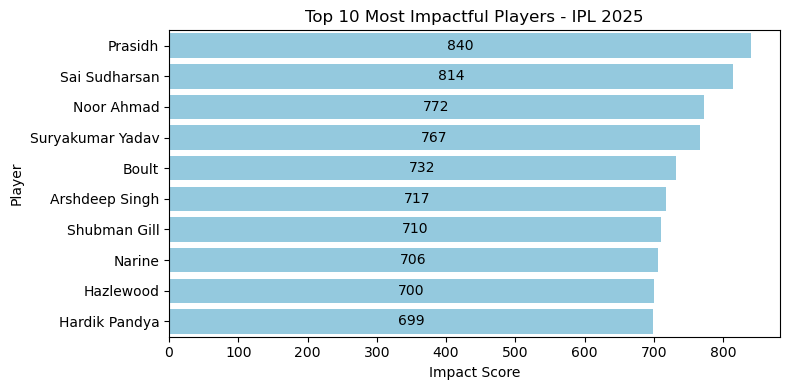

In [162]:


plt.figure(figsize=(8, 4))
ax = sns.barplot(data=impact.head(10), x='Impact_Score', y='Player',color='skyblue')
for containers in ax.containers:
    ax.bar_label(containers, label_type='center')
plt.title("Top 10 Most Impactful Players - IPL 2025")
plt.xlabel('Impact Score')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig('Top 10 Most Impactful Players - IPL 2025', dpi=150, bbox_inches='tight')
plt.show()
